### Before start, load inference environments, gpu, cuda, ...

In [1]:
from envs import actenv_jupyter, change_exp_dir, make_gpu_mem_reporter
actenv_jupyter(cuda_version="12.9", gcc_version="11", clear_cache=False)

[actenv_jupyter] CUDA_HOME=/usr/local/cuda-12.9
[actenv_jupyter] TORCH_CUDA_ARCH_LIST=8.0
[actenv_jupyter] CXX=/usr/bin/g++-11 | CC=/usr/bin/gcc-11
[actenv_jupyter] Ready.


{'CUDA_HOME': '/usr/local/cuda-12.9',
 'TORCH_CUDA_ARCH_LIST': '8.0',
 'CC': '/usr/bin/gcc-11',
 'CXX': '/usr/bin/g++-11',
 'CUDAHOSTCXX': '/usr/bin/g++-11',
 'CXXFLAGS': '-std=c++17',
 'PATH_head': '/usr/local/cuda-12.9/bin:/home/ids/yuhe/anaconda3/envs/styleGANenv/bin:/home/ids/yuhe/.vscode-server/cli/servers/Stable-94e8ae2b28cb5cc932b86e1070569c4463565c37/server/bin/remote-cli',
 'LD_LIBRARY_PATH_head': '/usr/local/cuda-12.9/lib64:/usr/local/cuda-12.9/lib64:$LD_LIBRARY_PATH',
 'TORCH_CUDA_VERBOSE_BUILD': '1',
 'MAX_JOBS': '1'}

### Set experiment dir and models' paths

In [ ]:
import torch
import os
import yaml

root_dir = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN"
sfe_root = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS"
medminist_path = '/home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets'
med_path = '/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging'

# Paths_models = {
  
#         "brats_edit": {
#         "stylegan_weights":     "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/pSp_models/stylegan2-brats_880k.pt",
#         "stylegan_weights_pkl": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/pSp_models/stylegan2-brats_880k.pt",
#         "pSp_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/pSp_models/brats/psp_brats_220k.pt",
#         "pSp_cs_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/cs_models/brats/iteration_150000.pt",
#         "inverter_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/sfe/brats_inverter.pt",
#         "sfe_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/sfe/refined_sfe_brats_170k.pt", 
#         "config_yaml_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/sfe/config.yaml", 
#         },   
#         }

Paths_models = {
  
        "brats_edit": {
        "stylegan_weights":     "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/pSp_models/stylegan2-brats_880k.pt",
        "stylegan_weights_pkl": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/pSp_models/stylegan2-brats_880k.pt",
        "pSp_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/pSp_models/brats/psp_brats_220k.pt",
        "pSp_cs_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/cs_models/brats/iteration_150000.pt",
        "inverter_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/sfe/brats_inverter.pt",
        "sfe_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/sfe/refined_sfe_brats_170k.pt", 
        "config_yaml_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/sfe/config.yaml", 
        },   
        }




change_exp_dir(sfe_root)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

experiment_name = "brats_edit"

sfe_ckpt_path = Paths_models[experiment_name]["sfe_path"]
config_yaml_path = Paths_models[experiment_name]["config_yaml_path"]
from omegaconf import OmegaConf
config = OmegaConf.load(config_yaml_path)

config.model.w_space_encoder = "pSp"
config.model.pSp_path = Paths_models[experiment_name]["pSp_path"]
config.model.pSp_cs_path = Paths_models[experiment_name]["pSp_cs_path"]
config.model.checkpoint_path = sfe_ckpt_path
config.model.batch_size = 4  # Set batch size for inference
config.model.inverter_pth = Paths_models[experiment_name]["inverter_path"]
config.model.channel_multiplier = 2  # Set channel multiplier

# Pretty YAML (my favorite)
from omegaconf import OmegaConf
print(OmegaConf.to_yaml(config))



cwd: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS
Using device: cuda
exp:
  config_dir: configs
  config: fse_cs_editor_train.yaml
  exp_dir: ./experiments/
  name: fse_cs_editor_train/pSp_encoder/brats_130k
  seed: 1
  root: .
  wandb: false
  wandb_project: sfe
  domain: human_faces
  exp_type: brats_edit
data:
  transform: face_256
  special_idx: 0
  dataset: brats_edit
train:
  train_runner: fse_editor_cs_double
  encoder_optimizer: ranger
  disc_optimizer: adam
  resume_path: ''
  val_metrics:
  - msssim
  - lpips
  - l2
  - fid
  start_step: 300000
  steps: 500000
  log_step: 1000
  checkpoint_step: 10000
  val_step: 1000
  train_dis: true
  dis_train_start_step: 45000
  bs_used_before_adv_loss: 8
  disc_edits: []
  direction: two_directions
  disc_fake: inv_image
  disc_real: edit_domain
  f_scale: 1.0
  force_sx_zeros: true
model:
  method: fse_full
  device: cuda:0
  batch_size: 4
  workers: 4
  checkpoint_path: /home/ids/yuh

In [11]:
2000/8

250.0

In [3]:
from envs import make_gpu_mem_reporter
print_memory = make_gpu_mem_reporter(gpu_index=0, clear_cache_on_setup=True)

print_memory("Before loading model")

from runners.simple_runner import SimpleRunner
runner = SimpleRunner(config=config)
sfe_model = runner.inference_runner
device = sfe_model.device

sfe_model.method.train()

print_memory("After loading model")


[Before loading model]
  - PyTorch Allocated : 0.00 GB
  - PyTorch Reserved  : 0.00 GB
  - Total GPU Used    : 0.51 GB / 40.00 GB

Device: cuda:0
[DEBUG----------------------------] channel_multiplier = 2
[DEBUG----------------------------] stylegan_size = 256
Using pSp as w encoder, loading pSp-cs model ....
Loading pSp from checkpoint: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/pSp_models/brats/psp_brats_220k.pt
Loading cs mlp from path: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/cs_models/brats/iteration_150000.pt
Loading discriminator from /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/pSp_models/stylegan2-brats_880k.pt
✅ checkpoint loaded via torch.load
→ discriminator sd family: rosinality
✅ load_disc_any(rosinality): loaded all 50 keys (no mismatch).
✅ discriminator loaded from STATE_DICT (rosinality)
Loading refined-pSp-cs model from checkpoint: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretr

In [4]:
from torchvision.utils import save_image
from utils.common_utils import tensor2im, get_keys, visualize_batch_grid
from inference_ipynb.inference_funcs import get_latents_cs, calculate_delta_by_latent, recon_by_latent_w, recon_by_delta, configure_datasets, preprocess_image, get_random_seeds
import shutil
from tqdm import tqdm
import random
import torch.nn.functional as F


## Image qualitative evaluation

Random seed: 15972
Loading dataset
Using dataset: brats_test_data2


  0%|          | 0/80 [00:00<?, ?it/s]


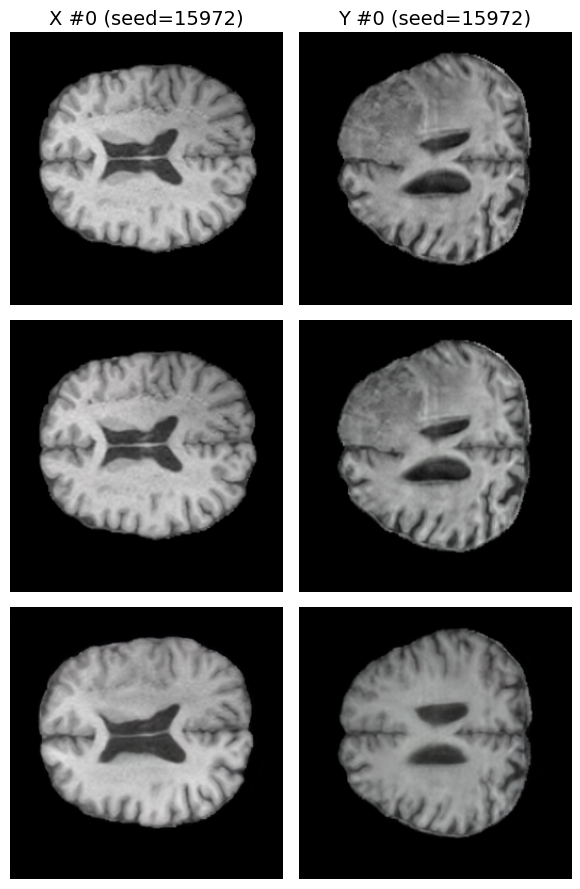

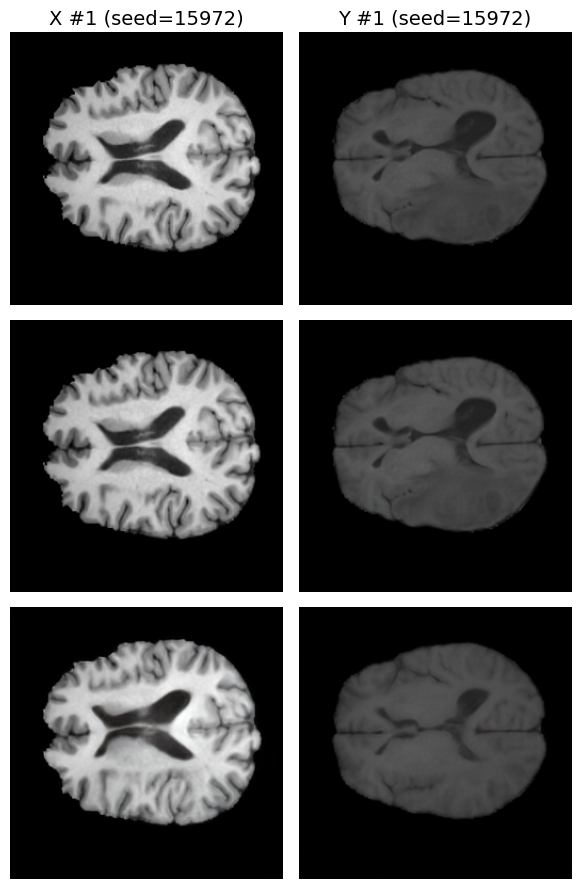

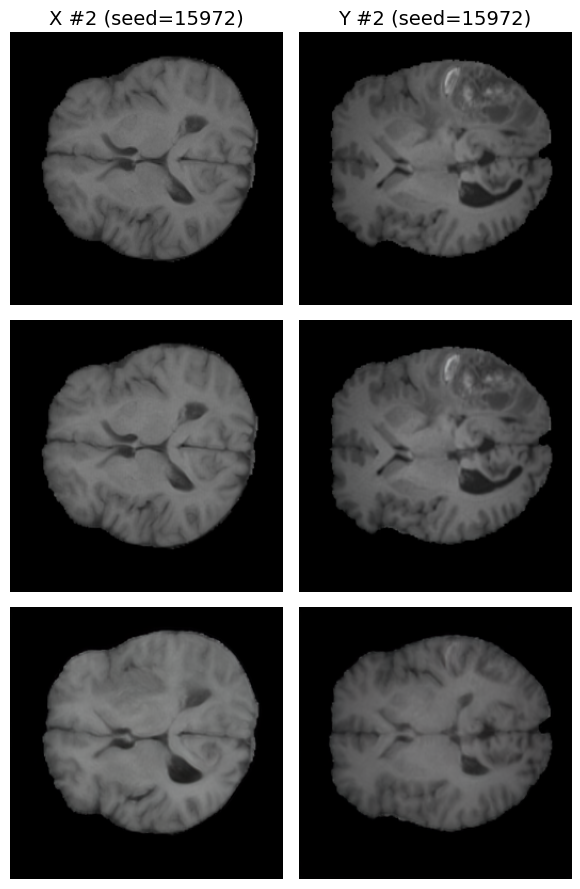

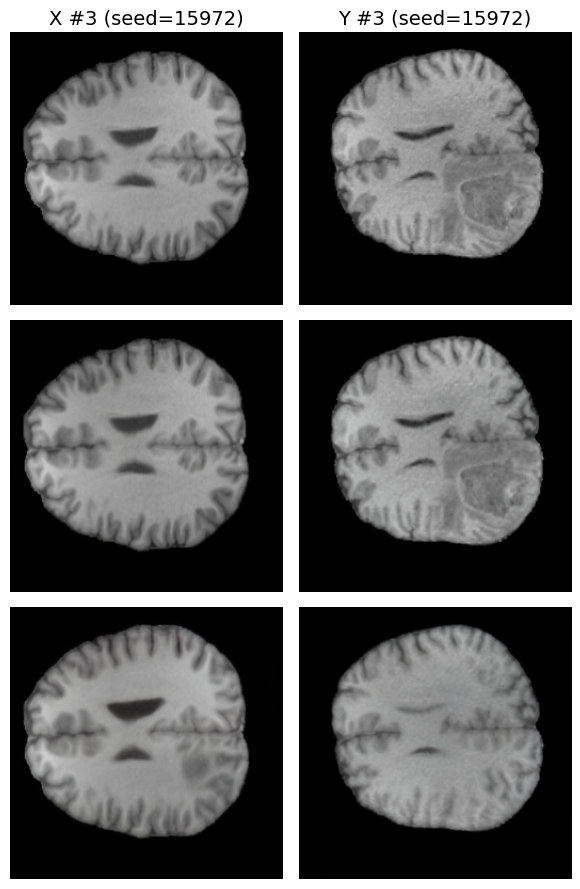

In [8]:
seed = get_random_seeds()
#seed = 19298
# === Get data ===

# sfe_model.config.data.dataset = 'octmnist_x3y0'
ds_name = 'brats_test_data2'
# ds_name = 'brats_ht_new'
test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=True, ds_name=ds_name)

with torch.no_grad():
    for batch_idx, (batch_bg, batch_t) in tqdm(enumerate(zip(test_bg_dataloader, test_t_dataloader)), total=len(test_bg_dataloader)):

        X = batch_bg.to(device).float()
        Y = batch_t.to(device).float()
        
        X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
        Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)        

        c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)
        s_x = torch.zeros_like(s_x)
        recon_w_X = recon_by_latent_w(c_x + s_x, sfe_model)
        recon_w_Y = recon_by_latent_w(c_y + s_y, sfe_model)

        swap_w_X2Y = recon_by_latent_w(c_x + s_y, sfe_model)
        swap_w_Y2X = recon_by_latent_w(c_y + s_x, sfe_model)

        recon_f_X = recon_by_delta(X_resh, delta=None, sfe_model=sfe_model)
        recon_f_Y = recon_by_delta(Y_resh, delta=None, sfe_model=sfe_model)

        delta_x2y = calculate_delta_by_latent(c_x + s_x, c_x + s_y, sfe_model)
        delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x, sfe_model)
        swap_f_X2Y = recon_by_delta(X_resh, delta_x2y, sfe_model)
        swap_f_Y2X = recon_by_delta(Y_resh, delta_y2x, sfe_model)
        
        break

num_pairs = 4
%matplotlib inline
for i in range(num_pairs):
    columns = []

    # Each column is one image (X or Y), stacked across rows
    col_X = torch.stack([
        X[i],                # Input X
        recon_f_X[i],        # Recon X
        swap_f_X2Y[i]        # Swap X→Y
    ], dim=0)

    col_Y = torch.stack([
        Y[i],                # Input Y
        recon_f_Y[i],        # Recon Y
        swap_f_Y2X[i]        # Swap Y→X
    ], dim=0)

    columns = [col_X, col_Y]

    titles  = [f"X #{i} (seed={seed})", f"Y #{i} (seed={seed})"]

    visualize_batch_grid(
        image_batches=columns,   # List of [3, C, H, W]
        titles=titles,           # Column titles
        save_path=None           # Or provide path to save
    )
# Image quantitative evaluation

# Image quantitative evaluation

In [ ]:
seed = get_random_seeds()
#seed = 19298
# === Get data ===
# sfe_model.config.data.dataset = 'bloodmnist'
ds_name = 'brats_ht_new'
# ds_name = 'brats_test_data2'
test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=False, ds_name=ds_name)

exp_name = f"brats_ht/{sfe_model.config.train.train_runner}/images/{ds_name}"
save_image_dir = f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/ours_brats/{exp_name}"

max_eval_batch = None

if os.path.exists(save_image_dir):
    shutil.rmtree(save_image_dir)

image_paths = ['real_X', 'real_Y', 'recon_w_X', 'recon_w_Y', 'swap_w_Y2X', 'swap_w_X2Y', 'recon_f_X', 'recon_f_Y', 'swap_f_X2Y', 'swap_f_Y2X']

for path in image_paths:
    dir_path = os.path.join(save_image_dir, path)
    os.makedirs(dir_path)


with torch.no_grad():
    for batch_idx, (batch_bg, batch_t) in tqdm(enumerate(zip(test_bg_dataloader, test_t_dataloader)), total=len(test_bg_dataloader)):
        if max_eval_batch is not None and batch_idx >= max_eval_batch:
            break

        X = batch_bg.to(device).float()
        Y = batch_t.to(device).float()
        
        X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
        Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)        

        c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)
        s_x = torch.zeros_like(s_x)
        recon_w_X = recon_by_latent_w(c_x + s_x, sfe_model)
        recon_w_Y = recon_by_latent_w(c_y + s_y, sfe_model)

        swap_w_X2Y = recon_by_latent_w(c_x + s_y, sfe_model)
        swap_w_Y2X = recon_by_latent_w(c_y + s_x, sfe_model)

        recon_f_X = recon_by_delta(X_resh, delta=None, sfe_model=sfe_model)
        recon_f_Y = recon_by_delta(Y_resh, delta=None, sfe_model=sfe_model)

        delta_x2y = calculate_delta_by_latent(c_x + s_x, c_x + s_y, sfe_model)
        delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x, sfe_model)
        swap_f_X2Y = recon_by_delta(X_resh, delta_x2y, sfe_model)
        swap_f_Y2X = recon_by_delta(Y_resh, delta_y2x, sfe_model)

        # collect (keys align with image_paths)
        images = {
            "real_X": X,
            "real_Y": Y,
            "recon_w_X": recon_w_X,
            "recon_w_Y": recon_w_Y,
            "recon_f_X": recon_f_X,
            "recon_f_Y": recon_f_Y,
            "swap_w_X2Y": swap_w_X2Y,
            "swap_w_Y2X": swap_w_Y2X,
            "swap_f_X2Y": swap_f_X2Y,
            "swap_f_Y2X": swap_f_Y2X,
        }



        # de-normalize / postprocess per tensor (skip None)
        images = {k: (None if v is None else preprocess_image(v)) for k, v in images.items()}

        # save all groups
        B = next(v.size(0) for v in images.values() if v is not None)
        for i in range(B):
            idx = batch_idx * B + i
            for key, tensor in images.items():
                if tensor is None or tensor.ndim != 4 or i >= tensor.size(0):
                    continue
                img_i = tensor[i].detach().cpu().clamp(0, 1)  # safety clamp
                save_image(img_i, os.path.join(save_image_dir, key, f"{idx}.png"))

    print(f"Results images saved to {save_image_dir}")


# num_pairs = 4
# %matplotlib inline
# for i in range(num_pairs):
#     columns = []

#     # Each column is one image (X or Y), stacked across rows
#     col_X = torch.stack([
#         X[i],                # Input X
#         recon_f_X[i],        # Recon X
#         swap_f_X2Y[i]        # Swap X→Y
#     ], dim=0)

#     col_Y = torch.stack([
#         Y[i],                # Input Y
#         recon_f_Y[i],        # Recon Y
#         swap_f_Y2X[i]        # Swap Y→X
#     ], dim=0)

#     columns = [col_X, col_Y]

#     titles  = [f"X #{i} (seed={seed})", f"Y #{i} (seed={seed})"]

#     visualize_batch_grid(
#         image_batches=columns,   # List of [3, C, H, W]
#         titles=titles,           # Column titles
#         save_path=None           # Or provide path to save
#     )


# #
# 14153 19298

Random seed: 10268
Loading dataset
Using dataset: brats_ht_new


100%|██████████| 521/521 [10:09<00:00,  1.17s/it]

Results images saved to /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/ours_brats/brats_ht/fse_editor_cs_double/images/brats_ht_new


## Latent separation evaluation

In [ ]:
seed = get_random_seeds()
#seed = 19298
# === Get data ===

ds_name = 'BraTS_evaluation'

test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=False, ds_name=ds_name)
exp_name = f"brats_ht/{sfe_model.config.train.train_runner}/latents/{ds_name}"
save_image_dir = f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/ours_brats/{exp_name}"

max_eval_batch = None

if os.path.exists(save_image_dir):
    shutil.rmtree(save_image_dir)

# Prepare directories for saving images
latent_paths = ['latents_x', 'latents_y']

for path in latent_paths:
    dir_path = os.path.join(save_image_dir, path)
    if os.path.exists(dir_path):
            shutil.rmtree(dir_path)
    os.makedirs(dir_path)


sfe_model.method.train()
with torch.no_grad():
    for batch_idx, (batch_bg, batch_t) in tqdm(enumerate(zip(test_bg_dataloader, test_t_dataloader)), total=len(test_bg_dataloader)):
        if max_eval_batch is not None and batch_idx >= max_eval_batch:
            break

        X = batch_bg.to(device).float()
        Y = batch_t.to(device).float()
        
        X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
        Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)        

        c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)

        # Group latents for background (x) and target (y)
        latents = {
            "x": {"c": c_x, "s": s_x},
            "y": {"c": c_y, "s": s_y},
        }

        # Save latents per sample
        batch_size = X.size(0)
        for i in range(batch_size):
            idx = batch_idx * batch_size + i
            for key in ["x", "y"]:
                save_path = os.path.join(save_image_dir, f"latents_{key}", f"latent_{key}_{idx}.pt")
                torch.save({k: v[i].cpu() for k, v in latents[key].items()}, save_path)


Random seed: 9367
Loading dataset
Using dataset: brats_test_data2


100%|██████████| 80/80 [00:08<00:00,  8.92it/s]


## Interpolation

Random seed: 4918
Loading dataset
Using dataset: brats_test_data2


  0%|          | 0/80 [00:00<?, ?it/s]


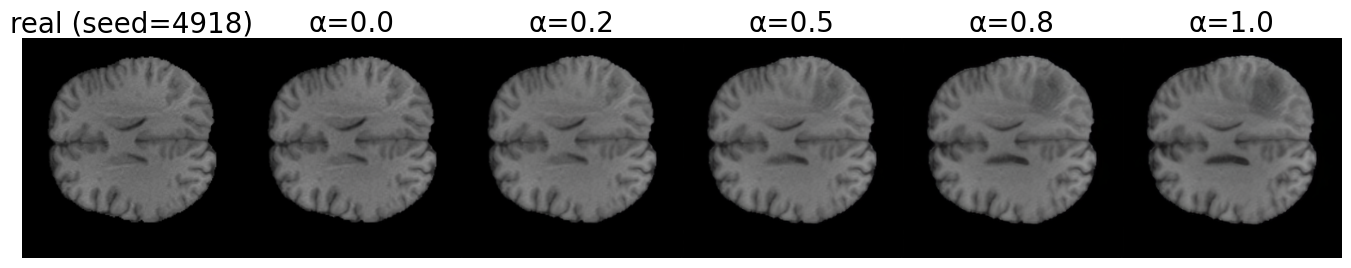

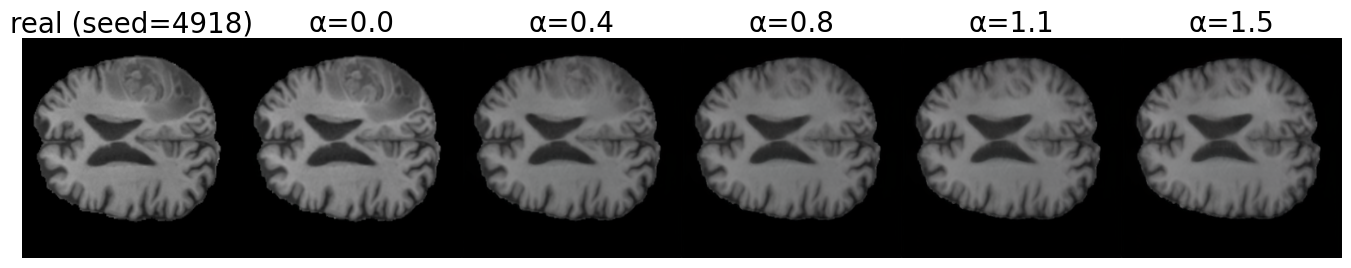

In [85]:
import torch
import matplotlib.pyplot as plt
seed = get_random_seeds()
#seed = 12830
# === Get data ===

ds_name = 'brats_test_data2'
test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=True, ds_name=ds_name)
# === Alpha Range ===
alphas_x = torch.linspace(0, 1, steps=5)
alphas_y = torch.linspace(0, 1.5, steps=5)
# alphas_x = alpha#[0.0000, 0.2000, 0.4000, 0.6000, 1.0000]
# alphas_y = alpha#[0.0000, 0.2000, 0.4000, 0.6000, 1.0000]

# === Prepare reconstructions ===
recon_w_X_alpha = []
recon_w_Y_alpha = []
recon_f_X_alpha = []
recon_f_Y_alpha = []

with torch.no_grad():
    for batch_idx, (batch_bg, batch_t) in tqdm(enumerate(zip(test_bg_dataloader, test_t_dataloader)), total=len(test_bg_dataloader)):

        
        X = batch_bg.to(device).float()
        Y = batch_t.to(device).float()
        
        X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
        Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)        

        # === Add Real Images First ===
        recon_w_X_alpha.append(X_resh)
        recon_w_Y_alpha.append(Y_resh)
        recon_f_X_alpha.append(X_resh)
        recon_f_Y_alpha.append(Y_resh)

        c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)
        s_x = torch.zeros_like(s_x)
        
        recon_w_X = recon_by_latent_w(c_x + s_x, sfe_model)
        recon_w_Y = recon_by_latent_w(c_y + s_y, sfe_model)
        recon_f_X = recon_by_delta(X_resh, delta=None, sfe_model=sfe_model)
        recon_f_Y = recon_by_delta(Y_resh, delta=None, sfe_model=sfe_model)

        for alpha_x, alpha_y in zip(alphas_x, alphas_y):
        #     s_interp_x2y = (1 - alpha_x) * s_x + alpha_x * s_y
        #     s_interp_y2x = (1 - alpha_y) * s_y + alpha_y * s_x
        #     recon_w_X_alpha.append(recon_by_latent_w(c_x + s_interp_x2y))
        #     recon_w_Y_alpha.append(recon_by_latent_w(c_y + s_interp_y2x))
        
            delta_x2y = calculate_delta_by_latent(c_x + s_x, c_x + s_y, sfe_model)
            delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x, sfe_model)
            
            swap_f_X2Y = recon_by_delta(X_resh, alpha_x * delta_x2y, sfe_model=sfe_model)
            swap_f_Y2X = recon_by_delta(Y_resh, alpha_y * delta_y2x, sfe_model=sfe_model)

            recon_f_X_alpha.append(swap_f_X2Y)
            recon_f_Y_alpha.append(swap_f_Y2X)
        
        break

titles_x = [f"real (seed={seed})"] + [f"α={a:.1f}" for a in alphas_x]
titles_y = [f"real (seed={seed})"] + [f"α={a:.1f}" for a in alphas_y]

# === Helper: Convert tensor to image ===
def tensor_to_img(t):
    t = ((t.clamp(-1, 1) + 1) / 2).detach().cpu()
    if t.shape[0] == 1:
        return t.squeeze(0).numpy()
    return t.permute(1, 2, 0).numpy()

# === Visualization ===
num_images = len(recon_f_X_alpha)
col_spacing = 0.0
title_height = 0.05
total_width = 1.0
idx = 3
img_width = (total_width - (num_images - 1) * col_spacing) / num_images


%matplotlib inline
# --- FIGURE 1: Y1 Row ---
fig_y1 = plt.figure(figsize=(num_images * 2.2, 2.5))
for i in range(num_images):
    left = i * (img_width + col_spacing)
    width = img_width

    ax = fig_y1.add_axes([left, 0, width, 1 - title_height])
    img = tensor_to_img(recon_f_X_alpha[i][idx])
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(titles_x[i], fontsize=20, pad=2)
    

plt.show()

# --- FIGURE 2: Y2 Row ---
fig_y2 = plt.figure(figsize=(num_images * 2.2, 2.5))
for i in range(num_images):
    left = i * (img_width + col_spacing)
    width = img_width

    ax = fig_y2.add_axes([left, 0, width, 1])
    img = tensor_to_img(recon_f_Y_alpha[i][idx])
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(titles_y[i], fontsize=20, pad=2)

plt.show()